In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("final_transport_data.csv")

print(df.columns)

Index(['TRANSPORT', 'NO_STOPS', 'DISTANCE', 'PRICE', 'DISTRICT',
       'NEXT DISTRICT', 'STOP_COUNT', 'STOP_COUNT_UNIQUE', 'AREA', 'DENSITY',
       'DENSITY_UNIQUE', 'DENSITY*10000', 'DENSITY_UNIQUE*100000',
       'LIVING POPULATION', 'WORKING POPULATION', 'BUILDING NUMBER',
       'ESTIMATED EMPLOYED POPULATION', 'MEDIAN MONTHLY INCOME',
       'NEXT STOP_COUNT', 'NEXT STOP_COUNT_UNIQUE', 'NEXT AREA',
       'NEXT DENSITY', 'NEXT DENSITY_UNIQUE', 'NEXT DENSITY*10000',
       'NEXT DENSITY_UNIQUE*100000', 'NEXT LIVING POPULATION',
       'NEXT WORKING POPULATION', 'NEXT BUILDING NUMBER',
       'NEXT ESTIMATED EMPLOYED POPULATION', 'NEXT MEDIAN MONTHLY INCOME',
       'PASS HARBOUR'],
      dtype='object')


In [12]:
print(df["TRANSPORT"].unique())

['BUS' 'MINIBUS' 'MTR' 'BUS->BUS' 'MINIBUS->BUS' 'MTR->MINIBUS' 'MTR->BUS'
 'BUS->MINIBUS' 'MINIBUS->MTR' 'BUS->MTR']


In [17]:
temp_dict = {
    "COMBINATION": [],
    "MEAN_NO_STOPS": [],
    "MEAN_DISTANCE": [],
    "COUNT": [],
    'STOP_COUNT': [],
    'STOP_COUNT_UNIQUE': [],
    'AREA': [],
    'DENSITY': [],
    'DENSITY_UNIQUE': [], 
    'DENSITY*10000': [], 
    'DENSITY_UNIQUE*100000': [],
    'LIVING POPULATION': [], 
    'WORKING POPULATION': [], 
    'BUILDING NUMBER': [],
    'ESTIMATED EMPLOYED POPULATION': [],
    'MEDIAN MONTHLY INCOME': [],
    'NEXT STOP_COUNT': [], 
    'NEXT STOP_COUNT_UNIQUE': [], 
    'NEXT AREA': [],
    'NEXT DENSITY': [], 
    'NEXT DENSITY_UNIQUE': [], 
    'NEXT DENSITY*10000': [],
    'NEXT DENSITY_UNIQUE*100000': [], 
    'NEXT LIVING POPULATION': [],
    'NEXT WORKING POPULATION': [], 
    'NEXT BUILDING NUMBER': [],
    'NEXT ESTIMATED EMPLOYED POPULATION': [], 
    'NEXT MEDIAN MONTHLY INCOME': [],
    "MEAN_PRICE": []
}
df = df[df["NO_STOPS"] > 0]

# Group by DISTRICT and NEXT DISTRICT
grouped_df = df.groupby(['DISTRICT', 'NEXT DISTRICT']).agg({
    'NO_STOPS': 'mean',
    'DISTANCE': 'mean',
    'STOP_COUNT': 'first',
    'STOP_COUNT_UNIQUE': 'first',
    'AREA': 'first',
    'DENSITY': 'first',
    'DENSITY_UNIQUE': 'first',
    'DENSITY*10000': 'first',
    'DENSITY_UNIQUE*100000': 'first',
    'LIVING POPULATION': 'first',
    'WORKING POPULATION': 'first',
    'BUILDING NUMBER': 'first',
    'MEDIAN MONTHLY INCOME': 'first',
    'NEXT STOP_COUNT': 'first',
    'NEXT STOP_COUNT_UNIQUE': 'first',
    'NEXT AREA': 'first',
    'NEXT DENSITY': 'first',
    'NEXT DENSITY_UNIQUE': 'first',
    'NEXT DENSITY*10000': 'first',
    'NEXT DENSITY_UNIQUE*100000': 'first',
    'NEXT LIVING POPULATION': 'first',
    'NEXT WORKING POPULATION': 'first',
    'NEXT BUILDING NUMBER': 'first',
    'NEXT ESTIMATED EMPLOYED POPULATION': 'first',
    'NEXT MEDIAN MONTHLY INCOME': 'first',
    "PRICE": "mean"
}).reset_index()

# Fill the temp_dict
for index, row in grouped_df.iterrows():
    temp_dict["COMBINATION"].append(f"{row['DISTRICT']} -> {row['NEXT DISTRICT']}")
    temp_dict["MEAN_NO_STOPS"].append(row['NO_STOPS'])
    temp_dict["MEAN_DISTANCE"].append(row['DISTANCE'])
    temp_dict["COUNT"].append(df[(df["DISTRICT"] == row['DISTRICT']) & (df["NEXT DISTRICT"] == row['NEXT DISTRICT'])].shape[0])
    temp_dict['STOP_COUNT'].append(row['STOP_COUNT'])
    temp_dict['STOP_COUNT_UNIQUE'].append(row['STOP_COUNT_UNIQUE'])
    temp_dict['AREA'].append(row['AREA'])
    temp_dict['DENSITY'].append(row['DENSITY'])
    temp_dict['DENSITY_UNIQUE'].append(row['DENSITY_UNIQUE'])
    temp_dict['DENSITY*10000'].append(row['DENSITY*10000'])
    temp_dict['DENSITY_UNIQUE*100000'].append(row['DENSITY_UNIQUE*100000'])
    temp_dict['LIVING POPULATION'].append(row['LIVING POPULATION'])
    temp_dict['WORKING POPULATION'].append(row['WORKING POPULATION'])
    temp_dict['BUILDING NUMBER'].append(row['BUILDING NUMBER'])
    temp_dict['ESTIMATED EMPLOYED POPULATION'].append(row['LIVING POPULATION'])
    temp_dict['MEDIAN MONTHLY INCOME'].append(row['MEDIAN MONTHLY INCOME'])
    temp_dict['NEXT STOP_COUNT'].append(row['NEXT STOP_COUNT'])
    temp_dict['NEXT STOP_COUNT_UNIQUE'].append(row['NEXT STOP_COUNT_UNIQUE'])
    temp_dict['NEXT AREA'].append(row['NEXT AREA'])
    temp_dict['NEXT DENSITY'].append(row['NEXT DENSITY'])
    temp_dict['NEXT DENSITY_UNIQUE'].append(row['NEXT DENSITY_UNIQUE'])
    temp_dict['NEXT DENSITY*10000'].append(row['NEXT DENSITY*10000'])
    temp_dict['NEXT DENSITY_UNIQUE*100000'].append(row['NEXT DENSITY_UNIQUE*100000'])
    temp_dict['NEXT LIVING POPULATION'].append(row['NEXT LIVING POPULATION'])
    temp_dict['NEXT WORKING POPULATION'].append(row['NEXT WORKING POPULATION'])
    temp_dict['NEXT BUILDING NUMBER'].append(row['NEXT BUILDING NUMBER'])
    temp_dict['NEXT ESTIMATED EMPLOYED POPULATION'].append(row['NEXT LIVING POPULATION'])
    temp_dict['NEXT MEDIAN MONTHLY INCOME'].append(row['NEXT MEDIAN MONTHLY INCOME'])
    temp_dict['MEAN_PRICE'].append(row['PRICE'])

# Convert to DataFrame
result_df = pd.DataFrame(temp_dict)

# Display result DataFrame
print(result_df)


KeyboardInterrupt: 

In [9]:
result_df.to_csv("summarised_data.csv", index=False)

In [9]:
import statsmodels.api as sm

result_df = pd.read_csv("summarised_data.csv")

result_df = result_df.dropna()

# Define your independent variables (X) and dependent variable (y)
X = result_df.iloc[:, 1:-1]  # All rows, all columns except the first and last
y = result_df.iloc[:, -1]     # Last column as the dependent variable

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Get the summary of the regression results
print(model.summary())

# Get p-values from the model summary
p_values = model.pvalues

# Identify variables with p-value greater than 0.05
median_p_value = p_values.median()
high_p_values = p_values[p_values > median_p_value].index.tolist()

X_no_w = X.drop(columns=["COUNT"], errors='ignore').drop(columns=high_p_values, errors='ignore')
X_no_w = sm.add_constant(X_no_w)
W = result_df["COUNT"]

model_w = sm.WLS(y, X_no_w, W).fit()
print(model_w.summary())

                            OLS Regression Results                            
Dep. Variable:             MEAN_PRICE   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     94.90
Date:                Fri, 02 May 2025   Prob (F-statistic):          1.80e-257
Time:                        11:19:33   Log-Likelihood:                -4338.5
No. Observations:                1529   AIC:                             8721.
Df Residuals:                    1507   BIC:                             8838.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

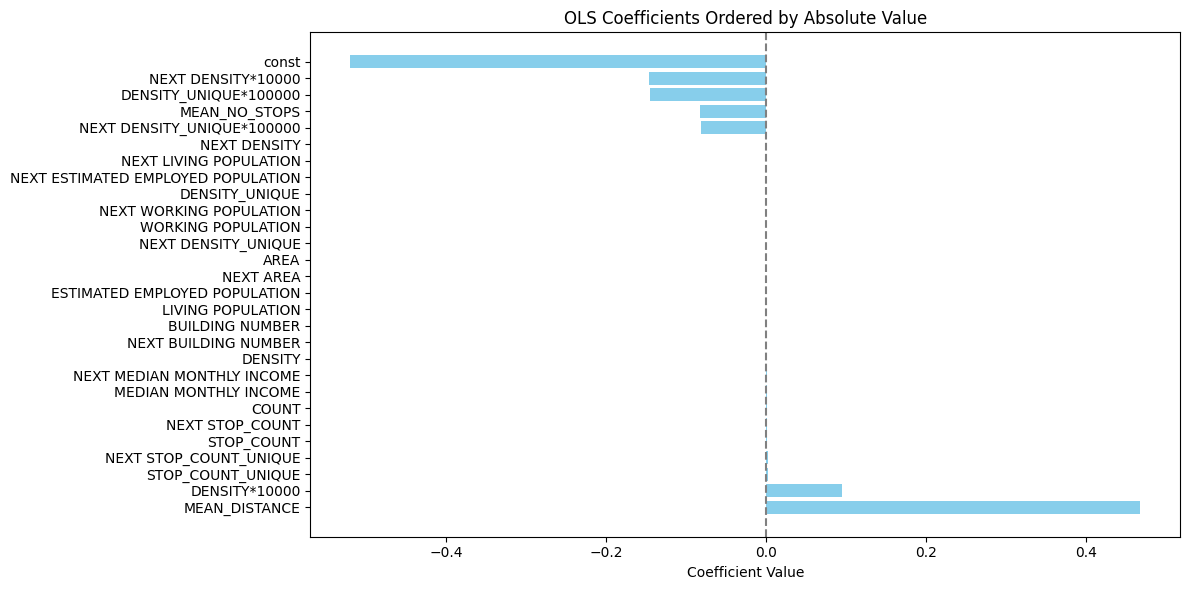

In [24]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Assuming 'model' is already defined and fitted

# Get the coefficients and their absolute values
coef = model.params

# Sort by absolute values
sorted_coef = coef[coef.sort_values(ascending=False).index]

# Plotting the coefficients
plt.figure(figsize=(12, 6))

plt.barh(sorted_coef.index, sorted_coef.values, color='skyblue')
plt.title('OLS Coefficients Ordered by Absolute Value')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='grey', linestyle='--')

plt.tight_layout()
plt.show()

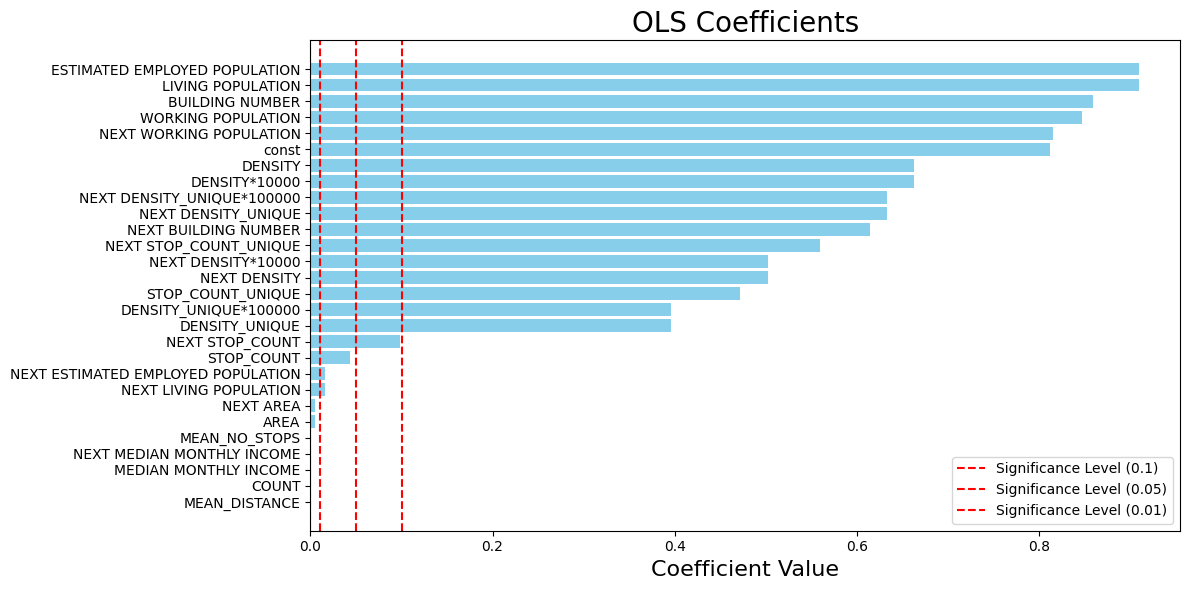

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Assuming 'model' is already defined and fitted

# Get the coefficients and their absolute values
coef = model.pvalues
abs_coef = coef.abs()

# Sort by absolute values
sorted_coef = coef[abs_coef.sort_values(ascending=True).index]

# Plotting the coefficients
plt.figure(figsize=(12, 6))

plt.barh(sorted_coef.index, sorted_coef.values, color='skyblue')
plt.title('OLS Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='grey', linestyle='--')
plt.axvline(0.1, color='red', linestyle='--', label='Significance Level (0.1)')
plt.axvline(0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.axvline(0.01, color='red', linestyle='--', label='Significance Level (0.01)')

plt.legend()

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

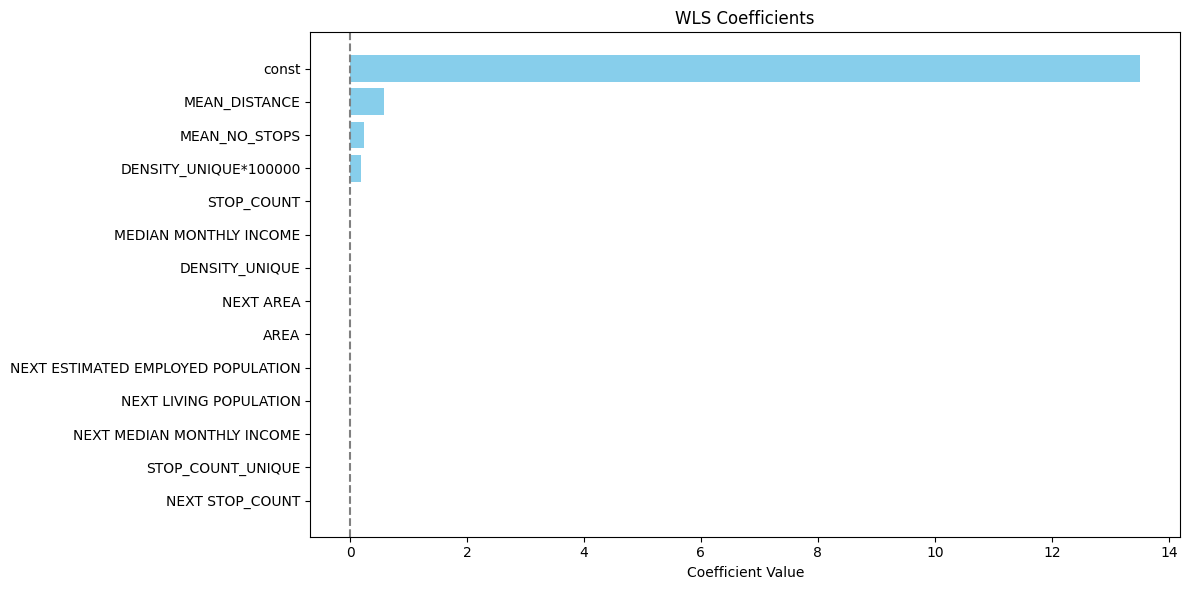

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


# Plotting the coefficients
plt.figure(figsize=(12, 6))
coef = model_w.params

# Sort by absolute values
sorted_coef = coef[coef.sort_values(ascending=True).index]

# Plotting the coefficients
plt.figure(figsize=(12, 6))

plt.barh(sorted_coef.index, sorted_coef.values, color='skyblue')
plt.title('WLS Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='grey', linestyle='--')

plt.tight_layout()
plt.show()

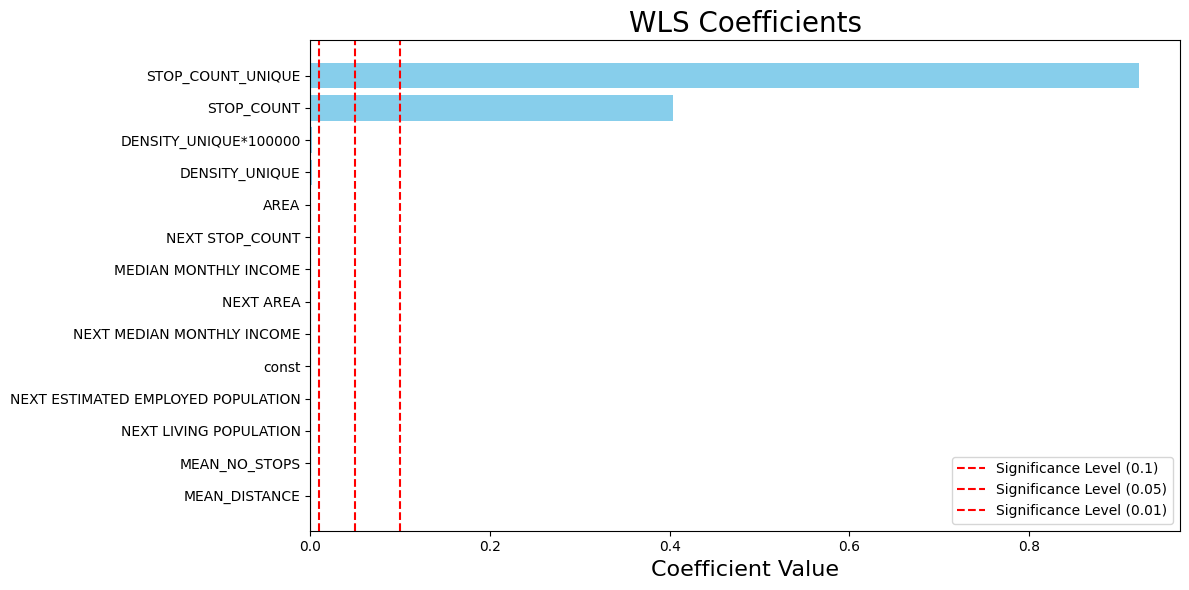

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Assuming 'model' is already defined and fitted

# Get the coefficients and their absolute values
coef = model_w.pvalues
abs_coef = coef.abs()

# Sort by absolute values
sorted_coef = coef[abs_coef.sort_values(ascending=True).index]

# Plotting the coefficients
plt.figure(figsize=(12, 6))

plt.barh(sorted_coef.index, sorted_coef.values, color='skyblue')
plt.title('WLS Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='grey', linestyle='--')
plt.axvline(0.1, color='red', linestyle='--', label='Significance Level (0.1)')
plt.axvline(0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.axvline(0.01, color='red', linestyle='--', label='Significance Level (0.01)')

plt.legend()

plt.tight_layout()
plt.show()